# USDA Economic Research Educational Attainment Data and
# USDA Economic Research Unemployment Data

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt


In [9]:
#read in the data
edu_data = pd.read_csv('Education2023_USDA_economic_research_service.txt', delimiter=',', encoding='utf-8', 
                       encoding_errors='ignore', dtype=str)
print(edu_data.shape)
edu_data.head(100)


(169245, 5)


,FIPS Code,State,Area name,Attribute,Value
0,0,US,United States,"Less than a high school diploma, 1970",52373312
1,0,US,United States,"High school diploma only, 1970",34158051
2,0,US,United States,"Some college (1-3 years), 1970",11650730
3,0,US,United States,"Four years of college or higher, 1970",11717266
4,0,US,United States,Percent of adults with less than a high school...,47.7
...,...,...,...,...,...
95,1000,AL,Alabama,Percent of adults with a bachelor's degree or ...,27.75513862
96,1001,AL,Autauga County,2013 Urban Influence Code,2
97,1001,AL,Autauga County,2024 Urban Influence Code,4
98,1001,AL,Autauga County,2013 Rural-urban Continuum Code,2


In [10]:
#looks like the FIPS codes are little wonky- we dont need the national level, 
#and it looks like leading zeros are missing from some of the county level, which could lead
# to later merging problems
edu_data = edu_data.drop(edu_data[edu_data['FIPS Code'] == '0'].index)
edu_data['FIPS Code'] = edu_data['FIPS Code'].apply(lambda x: x.zfill(5))
edu_data.head(100)


,FIPS Code,State,Area name,Attribute,Value
48,01000,AL,Alabama,"Less than a high school diploma, 1970",1062306
49,01000,AL,Alabama,"High school diploma only, 1970",468269
50,01000,AL,Alabama,"Some college (1-3 years), 1970",136287
51,01000,AL,Alabama,"Four years of college or higher, 1970",141936
52,01000,AL,Alabama,Percent of adults with less than a high school...,58.7
...,...,...,...,...,...
143,01001,AL,Autauga County,"Bachelor's degree or higher, 2019-23",11530
144,01001,AL,Autauga County,Percent of adults who are not high school grad...,9.721097947
145,01001,AL,Autauga County,Percent of adults who are high school graduate...,32.67593887
146,01001,AL,Autauga County,Percent of adults completing some college or a...,29.32028356


In [17]:
#only the rows with percentages are really useful, so let's just select those
edu_data = edu_data[edu_data['Attribute'].str.contains('Percent')] 
edu_data['Value'] = pd.to_numeric(edu_data['Value'], errors='coerce')
print(edu_data.shape)
edu_data.head(100)

(78155, 7)


,FIPS Code,State,Area name,Attribute,Value,Year,Category
52,01000,AL,Alabama,Percent of adults with less than a high school...,58.700000,1970,Percent of adults with less than a high school...
53,01000,AL,Alabama,Percent of adults with a high school diploma o...,25.900000,1970,Percent of adults with a high school diploma only
54,01000,AL,Alabama,Percent of adults completing some college (1-3...,7.500000,1970,Percent of adults completing some college (1-3...
55,01000,AL,Alabama,Percent of adults completing four years of col...,7.800000,1970,Percent of adults completing four years of col...
60,01000,AL,Alabama,Percent of adults with less than a high school...,43.500000,1980,Percent of adults with less than a high school...
...,...,...,...,...,...,...,...
251,01005,AL,Barbour County,Percent of adults with a bachelor's degree or ...,11.464715,2019,Percent of adults with a bachelor's degree or ...
260,01007,AL,Bibb County,Percent of adults with less than a high school...,73.100000,1970,Percent of adults with less than a high school...
261,01007,AL,Bibb County,Percent of adults with a high school diploma o...,19.400000,1970,Percent of adults with a high school diploma only
262,01007,AL,Bibb County,Percent of adults completing some college (1-3...,3.300000,1970,Percent of adults completing some college (1-3...


In [18]:
#now let's parse the attribute column
edu_data['Year'] = edu_data['Attribute'].str.extract(r'(\d{4})').astype(int)
edu_data['Category'] = edu_data['Attribute'].str.replace(r',?\s*\d{4}', '', regex=True).str.strip()
print(edu_data.shape)
edu_data.head()


(78155, 7)


,FIPS Code,State,Area name,Attribute,Value,Year,Category
52,01000,AL,Alabama,Percent of adults with less than a high school...,58.7,1970,Percent of adults with less than a high school...
53,01000,AL,Alabama,Percent of adults with a high school diploma o...,25.9,1970,Percent of adults with a high school diploma only
54,01000,AL,Alabama,Percent of adults completing some college (1-3...,7.5,1970,Percent of adults completing some college (1-3...
55,01000,AL,Alabama,Percent of adults completing four years of col...,7.8,1970,Percent of adults completing four years of col...
60,01000,AL,Alabama,Percent of adults with less than a high school...,43.5,1980,Percent of adults with less than a high school...


In [19]:
#now we need to pivot/melt for each attribute category, i.e. we want a column for "percent of adults with less than a high 
# school diploma", "percent of adults with a high school diploma", instead of the attribute categorical variable
edu_pivot = edu_data.pivot_table(index=['FIPS Code', 'State', 'Area name', 'Year'],columns='Category',values='Value').reset_index()
print(edu_pivot.shape)
edu_pivot.head(100)

(19539, 20)


Category,FIPS Code,State,Area name,Year,Percent of adults completing four years of college or higher,Percent of adults completing some college (1-3 years),Percent of adults completing some college or associate degree,Percent of adults completing some college or associate degree-12,Percent of adults completing some college or associate degree-23,Percent of adults who are high school graduates (or equivalent),Percent of adults who are high school graduates (or equivalent)-12,Percent of adults who are high school graduates (or equivalent)-23,Percent of adults who are not high school graduates,Percent of adults who are not high school graduates-12,Percent of adults who are not high school graduates-23,Percent of adults with a bachelor's degree or higher,Percent of adults with a bachelor's degree or higher-12,Percent of adults with a bachelor's degree or higher-23,Percent of adults with a high school diploma only,Percent of adults with less than a high school diploma
0,01000,AL,Alabama,1970,7.8,7.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.9,58.7
1,01000,AL,Alabama,1980,12.2,12.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.8,43.5
2,01000,AL,Alabama,1990,NaN,NaN,21.7,NaN,NaN,29.4,NaN,NaN,33.1,NaN,NaN,15.7,NaN,NaN,NaN,NaN
3,01000,AL,Alabama,2000,NaN,NaN,25.9,NaN,NaN,30.4,NaN,NaN,24.7,NaN,NaN,19.0,NaN,NaN,NaN,NaN
4,01000,AL,Alabama,2008,NaN,NaN,NaN,29.022866,NaN,NaN,31.309957,NaN,NaN,17.402281,NaN,NaN,22.264896,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,01029,AL,Cleburne County,2019,NaN,NaN,NaN,NaN,28.238652,NaN,NaN,38.94669,NaN,NaN,14.602707,NaN,NaN,18.211951,NaN,NaN
96,01031,AL,Coffee County,1970,5.8,7.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.0,59.9
97,01031,AL,Coffee County,1980,12.2,14.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.5,43.4
98,01031,AL,Coffee County,1990,NaN,NaN,24.5,NaN,NaN,26.3,NaN,NaN,32.8,NaN,NaN,16.5,NaN,NaN,NaN,NaN


In [20]:
#nans per column
print(edu_pivot.isna().sum())

Category
FIPS Code                                                                 0
State                                                                     0
Area name                                                                 0
Year                                                                      0
Percent of adults completing four years of college or higher          13088
Percent of adults completing some college (1-3 years)                 13088
Percent of adults completing some college or associate degree         12999
Percent of adults completing some college or associate degree-12      16266
Percent of adults completing some college or associate degree-23      16265
Percent of adults who are high school graduates (or equivalent)       12998
Percent of adults who are high school graduates (or equivalent)-12    16266
Percent of adults who are high school graduates (or equivalent)-23    16265
Percent of adults who are not high school graduates                   12998
Per

In [ ]:
# let's collapse some of the years so we just have a single value per category for each county, instead of multiple 
# for different years. we can take the mean across years for each county. let's do 2000 - 2010 for now. 
#first lets add a decade column
edu_pivot['Decade'] = (edu_pivot['Year'] // 10) * 10
#now we can group by FIPS code and decade, and take the mean
edu_decade = edu_pivot.groupby(['FIPS Code', 'State', 'Area name', 'Decade']).mean().reset_index()
print(edu_decade.shape)
edu_decade.head(100)

(16272, 21)


Category,FIPS Code,State,Area name,Decade,Year,Percent of adults completing four years of college or higher,Percent of adults completing some college (1-3 years),Percent of adults completing some college or associate degree,Percent of adults completing some college or associate degree-12,Percent of adults completing some college or associate degree-23,...,Percent of adults who are high school graduates (or equivalent)-12,Percent of adults who are high school graduates (or equivalent)-23,Percent of adults who are not high school graduates,Percent of adults who are not high school graduates-12,Percent of adults who are not high school graduates-23,Percent of adults with a bachelor's degree or higher,Percent of adults with a bachelor's degree or higher-12,Percent of adults with a bachelor's degree or higher-23,Percent of adults with a high school diploma only,Percent of adults with less than a high school diploma
0,01000,AL,Alabama,1970,1970.0,7.8,7.5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.9,58.7
1,01000,AL,Alabama,1980,1980.0,12.2,12.5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.8,43.5
2,01000,AL,Alabama,1990,1990.0,NaN,NaN,21.7,NaN,NaN,...,NaN,NaN,33.1,NaN,NaN,15.7,NaN,NaN,NaN,NaN
3,01000,AL,Alabama,2000,2004.0,NaN,NaN,25.9,29.022866,NaN,...,31.309957,NaN,24.7,17.402281,NaN,19.0,22.264896,NaN,NaN,NaN
4,01000,AL,Alabama,2010,2019.0,NaN,NaN,NaN,NaN,30.028286,...,NaN,30.344616,NaN,NaN,11.871959,NaN,NaN,27.755139,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,01037,AL,Coosa County,1970,1970.0,3.4,4.7,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.1,69.8
96,01037,AL,Coosa County,1980,1980.0,3.6,8.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.6,56.9
97,01037,AL,Coosa County,1990,1990.0,NaN,NaN,14.1,NaN,NaN,...,NaN,NaN,46.1,NaN,NaN,6.3,NaN,NaN,NaN,NaN
98,01037,AL,Coosa County,2000,2004.0,NaN,NaN,19.3,22.274010,NaN,...,43.861155,NaN,34.3,24.211947,NaN,8.0,9.652889,NaN,NaN,NaN


In [24]:
#let's pull just the data for the 2000s decade for now
edu_2000s = edu_decade[edu_decade['Decade'] == 2000]
print(edu_2000s.shape)
print(edu_2000s.isna().sum())
edu_2000s.head(100)

(3277, 21)
Category
FIPS Code                                                                0
State                                                                    0
Area name                                                                0
Decade                                                                   0
Year                                                                     0
Percent of adults completing four years of college or higher          3277
Percent of adults completing some college (1-3 years)                 3277
Percent of adults completing some college or associate degree            6
Percent of adults completing some college or associate degree-12         4
Percent of adults completing some college or associate degree-23      3277
Percent of adults who are high school graduates (or equivalent)          6
Percent of adults who are high school graduates (or equivalent)-12       4
Percent of adults who are high school graduates (or equivalent)-23    3277
Perce

Category,FIPS Code,State,Area name,Decade,Year,Percent of adults completing four years of college or higher,Percent of adults completing some college (1-3 years),Percent of adults completing some college or associate degree,Percent of adults completing some college or associate degree-12,Percent of adults completing some college or associate degree-23,...,Percent of adults who are high school graduates (or equivalent)-12,Percent of adults who are high school graduates (or equivalent)-23,Percent of adults who are not high school graduates,Percent of adults who are not high school graduates-12,Percent of adults who are not high school graduates-23,Percent of adults with a bachelor's degree or higher,Percent of adults with a bachelor's degree or higher-12,Percent of adults with a bachelor's degree or higher-23,Percent of adults with a high school diploma only,Percent of adults with less than a high school diploma
3,01000,AL,Alabama,2000,2004.0,NaN,NaN,25.9,29.022866,NaN,...,31.309957,NaN,24.7,17.402281,NaN,19.0,22.264896,NaN,NaN,NaN
8,01001,AL,Autauga County,2000,2004.0,NaN,NaN,26.9,29.618143,NaN,...,33.786706,NaN,21.3,14.887321,NaN,18.0,21.707831,NaN,NaN,NaN
13,01003,AL,Baldwin County,2000,2004.0,NaN,NaN,29.3,31.819503,NaN,...,28.816463,NaN,18.0,11.622443,NaN,23.1,27.741591,NaN,NaN,NaN
18,01005,AL,Barbour County,2000,2004.0,NaN,NaN,21.3,25.771784,NaN,...,33.294700,NaN,35.3,26.409230,NaN,10.9,14.524286,NaN,NaN,NaN
23,01007,AL,Bibb County,2000,2004.0,NaN,NaN,20.4,25.538085,NaN,...,41.609744,NaN,36.8,23.856167,NaN,7.1,8.996005,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
460,02240,AK,Southeast Fairbanks Census Area,2000,2004.0,NaN,NaN,33.5,39.026568,NaN,...,30.430900,NaN,13.2,8.238446,NaN,18.2,22.304086,NaN,NaN,NaN
466,02261,AK,Valdez-Cordova Census Area,2000,2004.0,NaN,NaN,37.4,42.686891,NaN,...,23.618635,NaN,11.5,10.044885,NaN,21.2,23.649590,NaN,NaN,NaN
467,02275,AK,Wrangell City and Borough,2000,2008.0,NaN,NaN,NaN,35.766836,NaN,...,33.276740,NaN,NaN,9.054895,NaN,NaN,21.901528,NaN,NaN,NaN
472,02280,AK,Wrangell-Petersburg Census Area,2000,2000.0,NaN,NaN,33.1,NaN,NaN,...,NaN,NaN,14.2,NaN,NaN,16.3,NaN,NaN,NaN,NaN


In [ ]:
#now lets drop the columsn that have a lot of nans, i.e. the ones for the higher education levels
edu_2000s = edu_2000s.drop(columns=['Percent of adults completing four years of college or higher',
                                    'Percent of adults completing some college (1-3 years)',
                                    'Percent of adults completing some college or associate degree-23',
                                    'Percent of adults who are high school graduates (or equivalent)-23',
                                    'Percent of adults who are not high school graduates-23',
                                    "Percent of adults with a bachelor's degree or higher-23",
                                    'Percent of adults with a high school diploma only',
                                     'Percent of adults with less than a high school diploma'])
print(edu_2000s.shape)
edu_2000s.head(100)                                    
                                    

(3277, 13)


Category,FIPS Code,State,Area name,Decade,Year,Percent of adults completing some college or associate degree,Percent of adults completing some college or associate degree-12,Percent of adults who are high school graduates (or equivalent),Percent of adults who are high school graduates (or equivalent)-12,Percent of adults who are not high school graduates,Percent of adults who are not high school graduates-12,Percent of adults with a bachelor's degree or higher,Percent of adults with a bachelor's degree or higher-12
3,01000,AL,Alabama,2000,2004.0,25.9,29.022866,30.4,31.309957,24.7,17.402281,19.0,22.264896
8,01001,AL,Autauga County,2000,2004.0,26.9,29.618143,33.8,33.786706,21.3,14.887321,18.0,21.707831
13,01003,AL,Baldwin County,2000,2004.0,29.3,31.819503,29.6,28.816463,18.0,11.622443,23.1,27.741591
18,01005,AL,Barbour County,2000,2004.0,21.3,25.771784,32.4,33.294700,35.3,26.409230,10.9,14.524286
23,01007,AL,Bibb County,2000,2004.0,20.4,25.538085,35.7,41.609744,36.8,23.856167,7.1,8.996005
...,...,...,...,...,...,...,...,...,...,...,...,...,...
460,02240,AK,Southeast Fairbanks Census Area,2000,2004.0,33.5,39.026568,35.1,30.430900,13.2,8.238446,18.2,22.304086
466,02261,AK,Valdez-Cordova Census Area,2000,2004.0,37.4,42.686891,29.9,23.618635,11.5,10.044885,21.2,23.649590
467,02275,AK,Wrangell City and Borough,2000,2008.0,NaN,35.766836,NaN,33.276740,NaN,9.054895,NaN,21.901528
472,02280,AK,Wrangell-Petersburg Census Area,2000,2000.0,33.1,NaN,36.5,NaN,14.2,NaN,16.3,NaN


In [26]:
#now we should be able to drop the NA rows without losing too much data
edu_2000s = edu_2000s.dropna()
print(edu_2000s.shape)

(3267, 13)


In [27]:
#export the cleaned data to a new csv file
edu_2000s.to_csv('education_2000s_cleaned.csv', index=False)

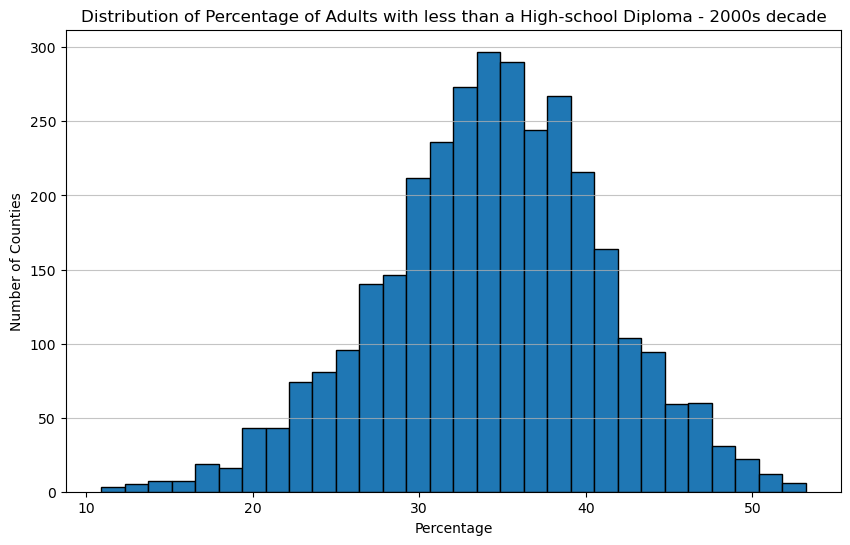

In [31]:
#visualization of the distribution of the percentage of adults with less than a high school diploma across counties in the 2000s decade
plt.figure(figsize=(10,6))
plt.hist(edu_2000s['Percent of adults who are high school graduates (or equivalent)'], bins=30, edgecolor='black')
plt.title('Distribution of Percentage of Adults with less than a High-school Diploma - 2000s decade')
plt.xlabel('Percentage')
plt.ylabel('Number of Counties')
plt.grid(axis='y', alpha=0.75)
plt.show()

Interesting, looks very Normally distributed. 

## Unemployment Data

In [49]:
emp_data = pd.read_csv('Unemployment2023_USDA_economic_research_service.csv', delimiter=',', encoding='utf-8', dtype=str)
#convert the value column to numeric, coercing errors to NaN
emp_data['Value'] = pd.to_numeric(emp_data['Value'], errors='coerce')
print(emp_data.shape)
emp_data.head(100)

(329726, 5)


,FIPS_Code,State,Area_Name,Attribute,Value
0,0,US,United States,Civilian_labor_force_2000,142601576.0
1,0,US,United States,Employed_2000,136904853.0
2,0,US,United States,Unemployed_2000,5696723.0
3,0,US,United States,Unemployment_rate_2000,4.0
4,0,US,United States,Civilian_labor_force_2001,143786537.0
...,...,...,...,...,...
95,0,US,United States,Unemployment_rate_2023,3.6
96,0,US,United States,Median_Household_Income_2022,74755.0
97,1000,AL,Alabama,Civilian_labor_force_2000,2147173.0
98,1000,AL,Alabama,Employed_2000,2047731.0


In [50]:
#okay so this looks very similar to the education data, so let's do basically the same things

#first fips
emp_data = emp_data.drop(emp_data[emp_data['FIPS_Code'] == '0'].index)
emp_data['FIPS_Code'] = emp_data['FIPS_Code'].apply(lambda x: x.zfill(5))
emp_data.head(100)

#select just the rows that have "Unemployment_rate" in the row string, and convert the value column to numeric
emp_data = emp_data[emp_data['Attribute'].str.contains("Unemployment_rate")]
emp_data['Value'] = pd.to_numeric(emp_data['Value'], errors='coerce')
print(emp_data.shape)
emp_data.head(100)

(78395, 5)


,FIPS_Code,State,Area_Name,Attribute,Value
100,01000,AL,Alabama,Unemployment_rate_2000,4.6
104,01000,AL,Alabama,Unemployment_rate_2001,5.2
108,01000,AL,Alabama,Unemployment_rate_2002,5.9
112,01000,AL,Alabama,Unemployment_rate_2003,6.0
116,01000,AL,Alabama,Unemployment_rate_2004,5.6
...,...,...,...,...,...
495,01005,AL,"Barbour County, AL",Unemployment_rate_2023,4.4
504,01007,AL,"Bibb County, AL",Unemployment_rate_2000,5.4
508,01007,AL,"Bibb County, AL",Unemployment_rate_2001,6.8
512,01007,AL,"Bibb County, AL",Unemployment_rate_2002,7.0


In [51]:
#parse out the year from the attribute column, and create a new column for it
emp_data['Year'] = emp_data['Attribute'].str.extract(r'(\d{4})').astype(int)
#remove the year from the attribute column to create a category column
emp_data['Category'] = emp_data['Attribute'].str.replace(r',?\s*\d{4}', '', regex=True).str.strip()
print(emp_data.shape)
emp_data.head(100)

(78395, 7)


,FIPS_Code,State,Area_Name,Attribute,Value,Year,Category
100,01000,AL,Alabama,Unemployment_rate_2000,4.6,2000,Unemployment_rate_
104,01000,AL,Alabama,Unemployment_rate_2001,5.2,2001,Unemployment_rate_
108,01000,AL,Alabama,Unemployment_rate_2002,5.9,2002,Unemployment_rate_
112,01000,AL,Alabama,Unemployment_rate_2003,6.0,2003,Unemployment_rate_
116,01000,AL,Alabama,Unemployment_rate_2004,5.6,2004,Unemployment_rate_
...,...,...,...,...,...,...,...
495,01005,AL,"Barbour County, AL",Unemployment_rate_2023,4.4,2023,Unemployment_rate_
504,01007,AL,"Bibb County, AL",Unemployment_rate_2000,5.4,2000,Unemployment_rate_
508,01007,AL,"Bibb County, AL",Unemployment_rate_2001,6.8,2001,Unemployment_rate_
512,01007,AL,"Bibb County, AL",Unemployment_rate_2002,7.0,2002,Unemployment_rate_


In [52]:
#okay now let's add the decade column
emp_data['Decade'] = (emp_data['Year'] // 10) * 10
#now we can group by FIPS code and decade, and take the mean
emp_decade = emp_data.groupby(['FIPS_Code', 'State', 'Area_Name', 'Category', 'Decade'])['Value'].mean().reset_index()
print(emp_decade.shape)
emp_decade.head(100)

#then let's pivot so we have a column for the unemployment rate
emp_pivot = emp_decade.pivot_table(index=['FIPS_Code', 'State', 'Decade'], columns='Category', values='Value').reset_index()
print(emp_pivot.shape)
emp_pivot.head(100)


(9812, 6)
(9812, 4)


Category,FIPS_Code,State,Decade,Unemployment_rate_
0,01000,AL,2000,5.570
1,01000,AL,2010,6.580
2,01000,AL,2020,3.700
3,01001,AL,2000,4.740
4,01001,AL,2010,5.710
...,...,...,...,...
95,01061,AL,2020,3.000
96,01063,AL,2000,8.130
97,01063,AL,2010,11.470
98,01063,AL,2020,6.775


In [53]:
#lets pull the 2000s decade for now
emp_2000s = emp_pivot[emp_pivot['Decade'] == 2000]
print(emp_2000s.shape)
print(emp_2000s.isna().sum())
emp_2000s.head(100)

(3269, 4)
Category
FIPS_Code             0
State                 0
Decade                0
Unemployment_rate_    0
dtype: int64


Category,FIPS_Code,State,Decade,Unemployment_rate_
0,01000,AL,2000,5.57
3,01001,AL,2000,4.74
6,01003,AL,2000,4.71
9,01005,AL,2000,7.51
12,01007,AL,2000,6.15
...,...,...,...,...
290,02290,AK,2000,12.69
293,04000,AZ,2000,5.40
296,04001,AZ,2000,10.84
299,04003,AZ,2000,5.26


In [54]:
#export the cleaned unemployment data for the 2000s decade
emp_2000s.to_csv('unemployment_2000s_cleaned.csv', index=False)

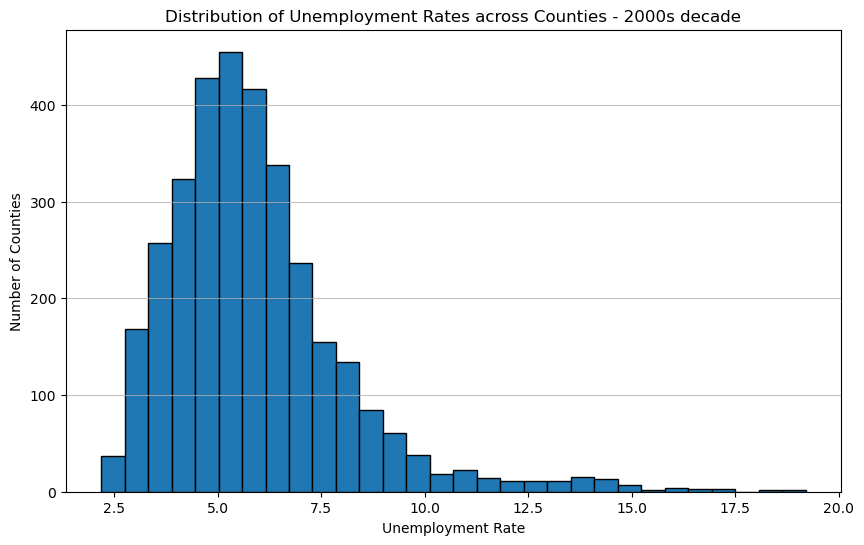

In [56]:
#visualize the dist of unemployment rates across counties in the 2000s decade
plt.figure(figsize=(10,6))
plt.hist(emp_2000s['Unemployment_rate_'], bins=30, edgecolor='black')
plt.title('Distribution of Unemployment Rates across Counties - 2000s decade')
plt.xlabel('Unemployment Rate')
plt.ylabel('Number of Counties')
plt.grid(axis='y', alpha=0.75)
plt.show()

Looks right-skewed